### Energy Spectra

This chapter examines how energy is distributed across different spatial scales
in the atmosphere by computing and comparing the energy spectra of both models.
This analysis is critical in understanding the models' capabilities to simulate
atmospheric processes ranging from large-scale weather systems to small-scale
turbulence.

**FFT Computation:** The Fast Fourier Transform (FFT) is used to transform spatial data into the frequency domain, revealing how different scales contribute to the overall energy. The energy spectra are averaged over latitudes.

**Scale Representation:** The energy spectra show whether the ML model captures the correct amount of energy at various spatial scales.

**Effective Resolution:** Identifying the effective resolution helps understand the smallest scales that the model can reliably simulate.

**Numerical Artifacts:** Limitations in numerical precision can introduce artifacts in the spectra, especially at the smallest scales.

To interpret the Log-Spectral Distance (LSD) metric:
The LSD quantifies the difference between two spectra, with lower values indicating better similarity (area between the two spectra). 

Lower values indicate better similarity between spectra
- LSD = 0 means identical spectra

Typical values depend on the specific application, but generally:
- LSD < 1: Good similarity
- 1 < LSD < 2: Moderate differences
- LSD > 2: Significant differences

In [20]:
from collections import OrderedDict
import torch
from neural_lam import constants, utils, vis, config, metrics
import matplotlib.pyplot as plt
import numpy as np

data_config = config.Config.from_file("../data_config.yaml")
static_data_dict = utils.load_static_data("meps")
model_lookup = OrderedDict()
kwargs = {}

prediction_path = "predictions"
output_path = "spectra_plots"
time_step = 18 # 0-18, 3 hour intervals

# Models
model_lookup["prob_hi"] = "Graph-EFM"
model_lookup["diff"] = "Diffusion-LAM"
model_lookup["crps"] = "CRPS-LAM"

/proj/berzelius-2022-164/users/x_erila/neural-lam/neural_lam/utils.py:49: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.load(


In [22]:
# Replace the loading cell with:
models_data = {}  # Create a separate dictionary for the loaded data
for key, model_name in model_lookup.items():
    # Define the filenames for each prediction type
    filenames = {
        "target": f"{prediction_path}/{model_name}/ground_truth_spectra.pt",
        "predictions": f"{prediction_path}/{model_name}/model_spectra.pt",
    }
    
    # Load the predictions into a dictionary
    predictions = {}
    for pred_type, filepath in filenames.items():
        try:
            predictions[pred_type] = torch.load(filepath, map_location=torch.device('cpu'))
            print(f"Loaded {pred_type} from {filepath}, with shape {predictions[pred_type].shape}")
        except FileNotFoundError:
            print(f"Warning: File {filepath} not found.")
    
    # Store the predictions in a separate dictionary
    models_data[key] = {
        "model_name": model_name,
        "predictions": predictions,
    }

Loaded target from predictions/Graph-EFM/ground_truth_spectra.pt, with shape torch.Size([19, 17, 166])
Loaded predictions from predictions/Graph-EFM/model_spectra.pt, with shape torch.Size([19, 17, 166])
Loaded target from predictions/Diffusion-LAM/ground_truth_spectra.pt, with shape torch.Size([19, 17, 166])
Loaded predictions from predictions/Diffusion-LAM/model_spectra.pt, with shape torch.Size([19, 17, 166])
Loaded target from predictions/CRPS-LAM/ground_truth_spectra.pt, with shape torch.Size([19, 17, 166])
Loaded predictions from predictions/CRPS-LAM/model_spectra.pt, with shape torch.Size([19, 17, 166])


/tmp/ipykernel_2439305/3369801575.py:14: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  predictions[pred_type] = torch.load(filepath, map_location=torch.device('cpu'))


In [30]:
def plot_energy_spectra(spectra_gt, model_lookup, var, time_step=None, title=None, show_legend=True):
    """Plot energy spectra comparison using pre-calculated spectra.
    
    Parameters:
    -----------
    spectra_gt : torch.Tensor
        Ground truth spectra with shape [time_steps, variables, spectra_bins]
    model_lookup : dict
        Dictionary of model data
    var : int
        Variable index to plot
    time_step : int, optional
        Time step to plot. If None, averages across all time steps.
    title : str, optional
        Custom title for the plot
    show_legend : bool
        Whether to show the legend
    """
    fig, ax = plt.subplots(figsize=(11, 6.5), dpi=300)
    x = np.arange(0, spectra_gt.shape[-1])

    if time_step is not None:
        # Single time step case
        # Plot ground truth spectrum
        ax.loglog(
            x,
            spectra_gt[time_step, var, :].cpu().numpy(),
            label="Ground Truth",
        )

        for key, model in model_lookup.items():
            spectra_ml = model["predictions"]["predictions"][time_step, var, :].cpu().numpy()
            # Plot ML spectrum
            ax.loglog(
                x,
                spectra_ml,
                label=model["model_name"],
            )
        
        time_str = f"at time step {(time_step+1)*3}h"
    else:
        # Average across all time steps
        # Get the number of time steps
        time_steps = spectra_gt.shape[0]
        
        # Average ground truth spectra across time
        avg_gt_spectrum = torch.mean(spectra_gt[:, var, :], dim=0).cpu().numpy()
        ax.loglog(
            x,
            avg_gt_spectrum,
            label="Ground Truth",
        )

        for key, model in model_lookup.items():
            # Average model spectra across time
            avg_ml_spectrum = torch.mean(model["predictions"]["predictions"][:, var, :], dim=0).cpu().numpy()
            ax.loglog(
                x,
                avg_ml_spectrum,
                label=model["model_name"],
            )
        
        time_str = "averaged across all time steps"

    # Customize plot
    ax.set_xlabel("Wavenumber (1/m)")
    unit = constants.PARAM_UNITS[constants.USED_PARAMS][var]
    ax.set_ylabel(f"Energy Density (({unit})² * m)")
    var_name = constants.PARAM_NAMES_SHORT[constants.USED_PARAMS][var]
    title = title if title is not None else f"Energy Spectra Comparison for {var_name} {time_str}"
    ax.set_title(title)
    if show_legend:
        ax.legend(loc='upper right')
    ax.grid(True, which="both", ls="--", alpha=0.5)
    plt.tight_layout()

    return fig


def add_lsd_to_plot(ax, true_spectrum, ml_spectrum):
    """
    Add LSD metric as text box to spectrum plot
    """
    lsd_ml = metrics.calculate_log_spectral_distance(
        true_spectrum, ml_spectrum
    )
    textstr = f"LSD = {lsd_ml:.4f}"

    props = dict(boxstyle="round", facecolor="wheat", alpha=0.5)
    ax.text(
        0.05,
        0.1,
        textstr,
        transform=ax.transAxes,
        verticalalignment="top",
        bbox=props,
    )

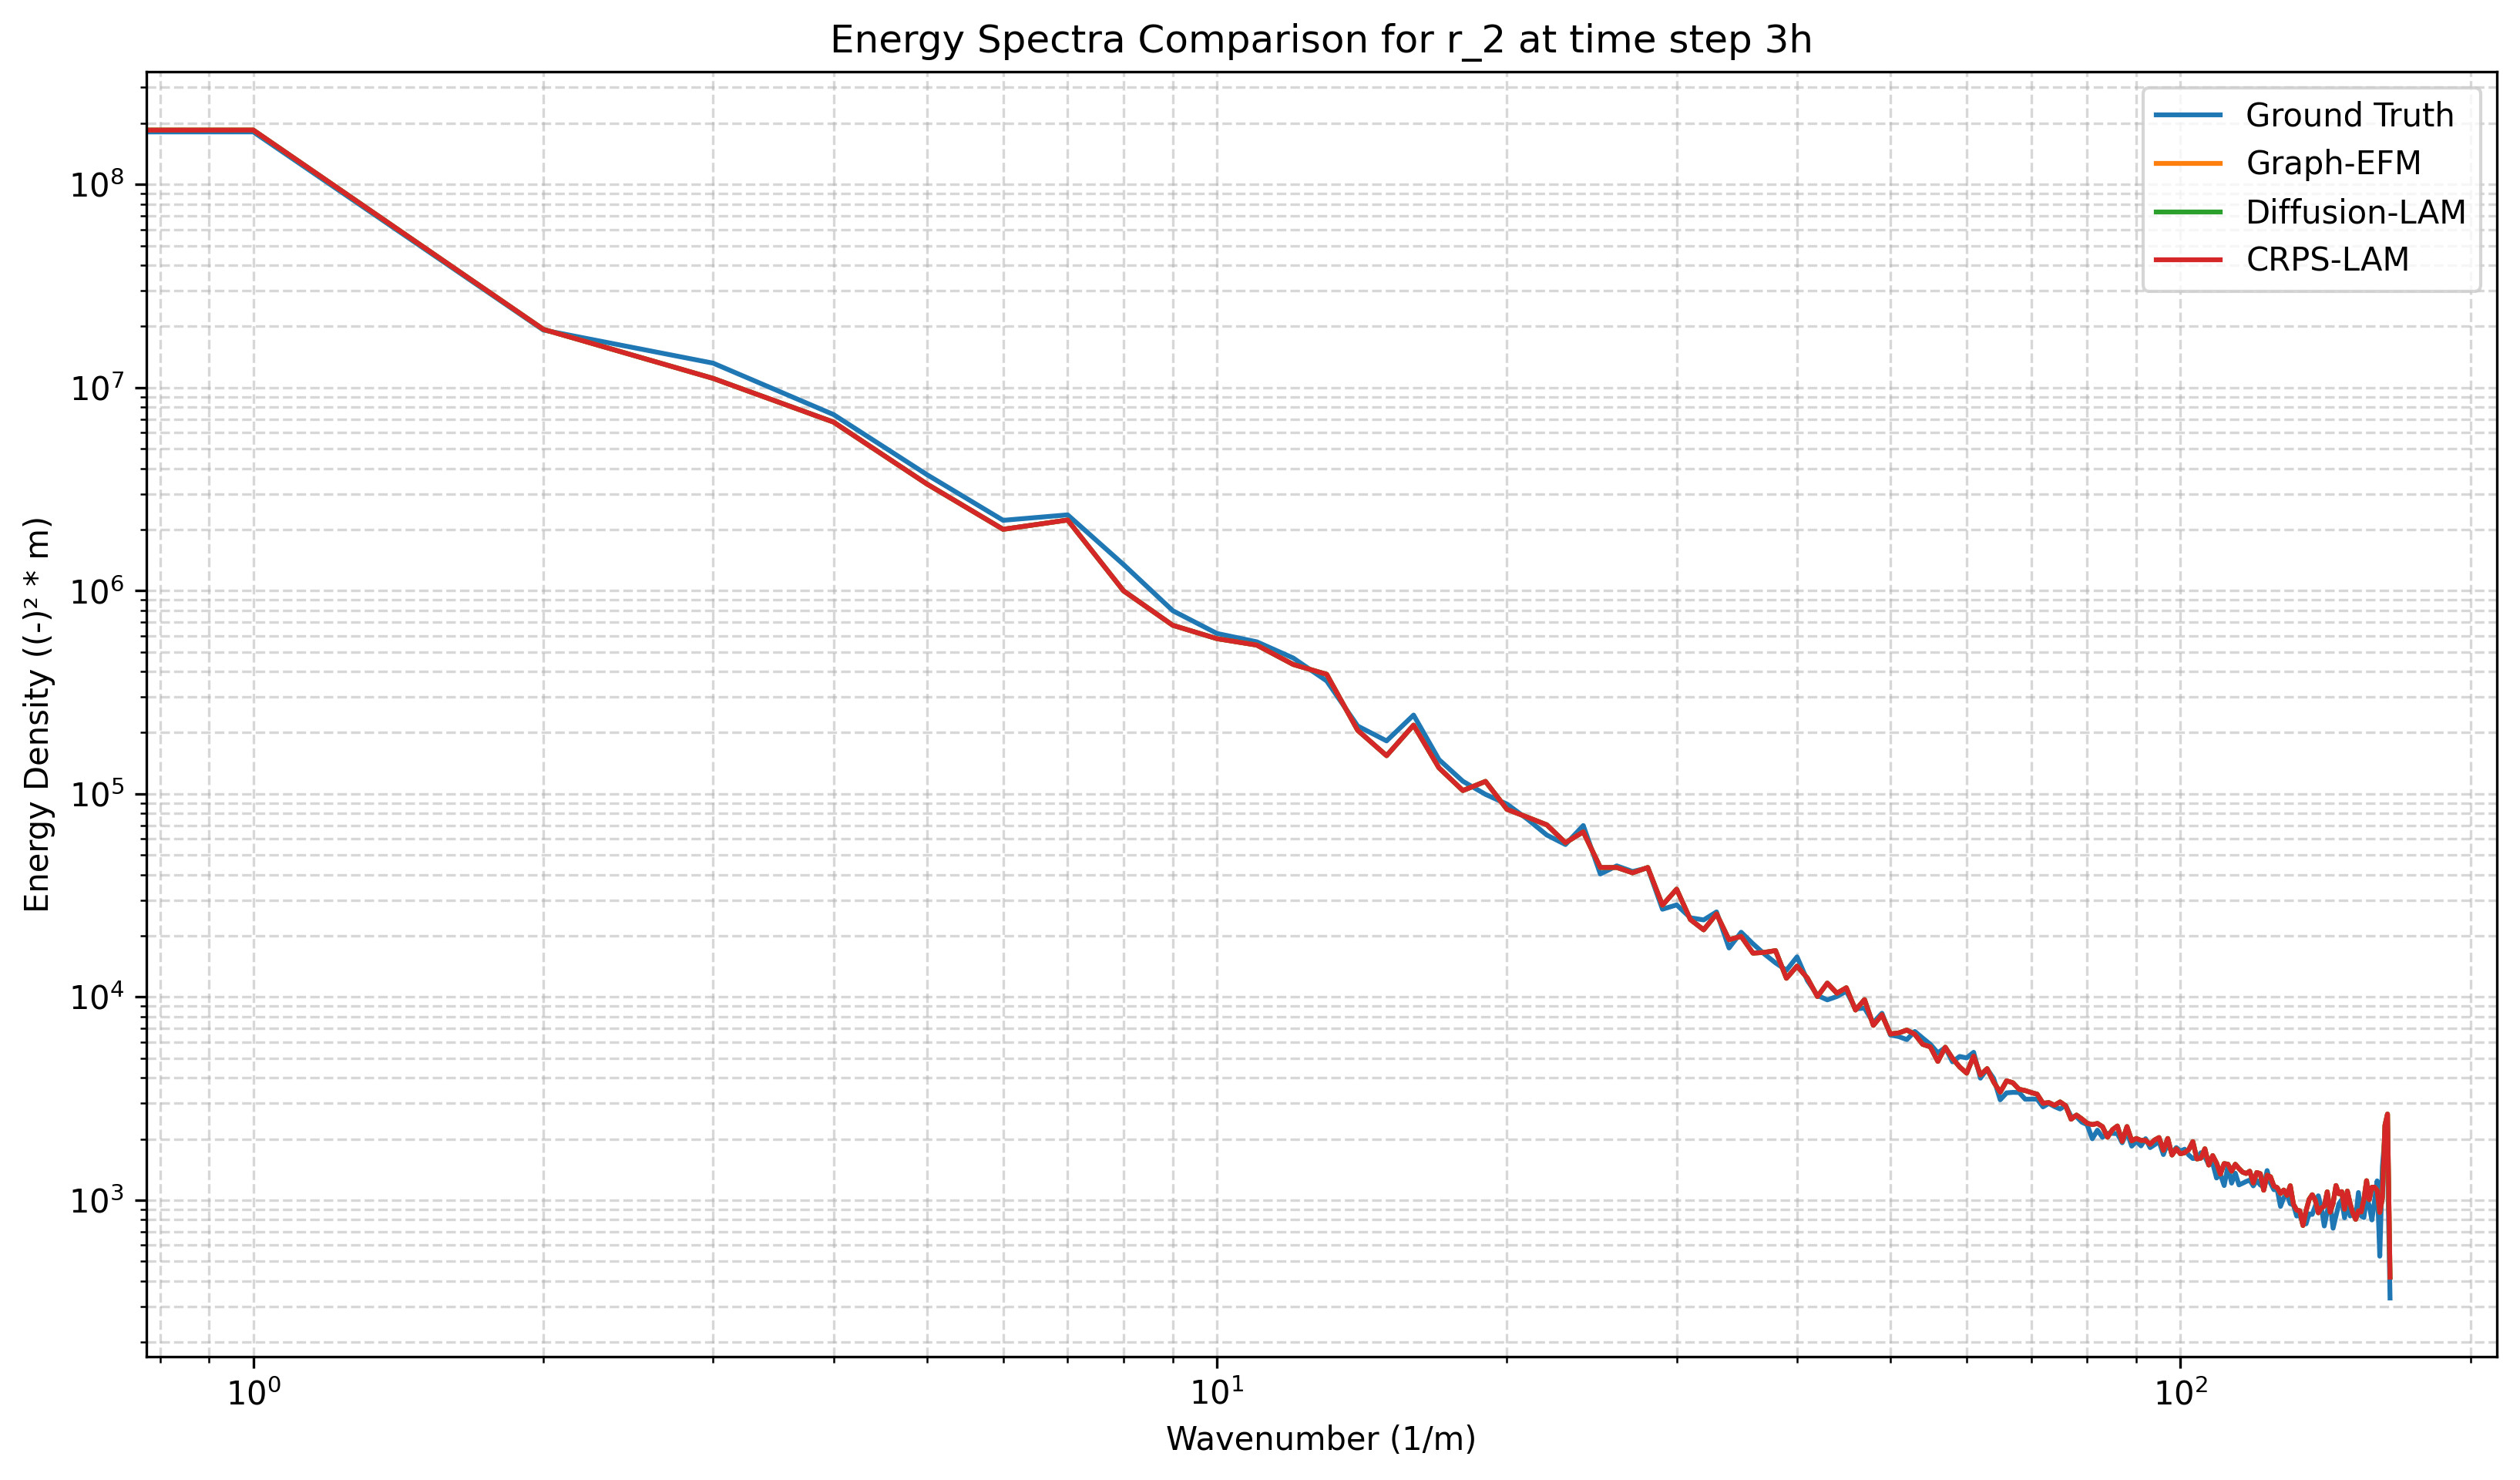

In [31]:
# Plot spectra for specific variable and lead time
fig = plot_energy_spectra(models_data["diff"]["predictions"]["target"], models_data, 4, 0)

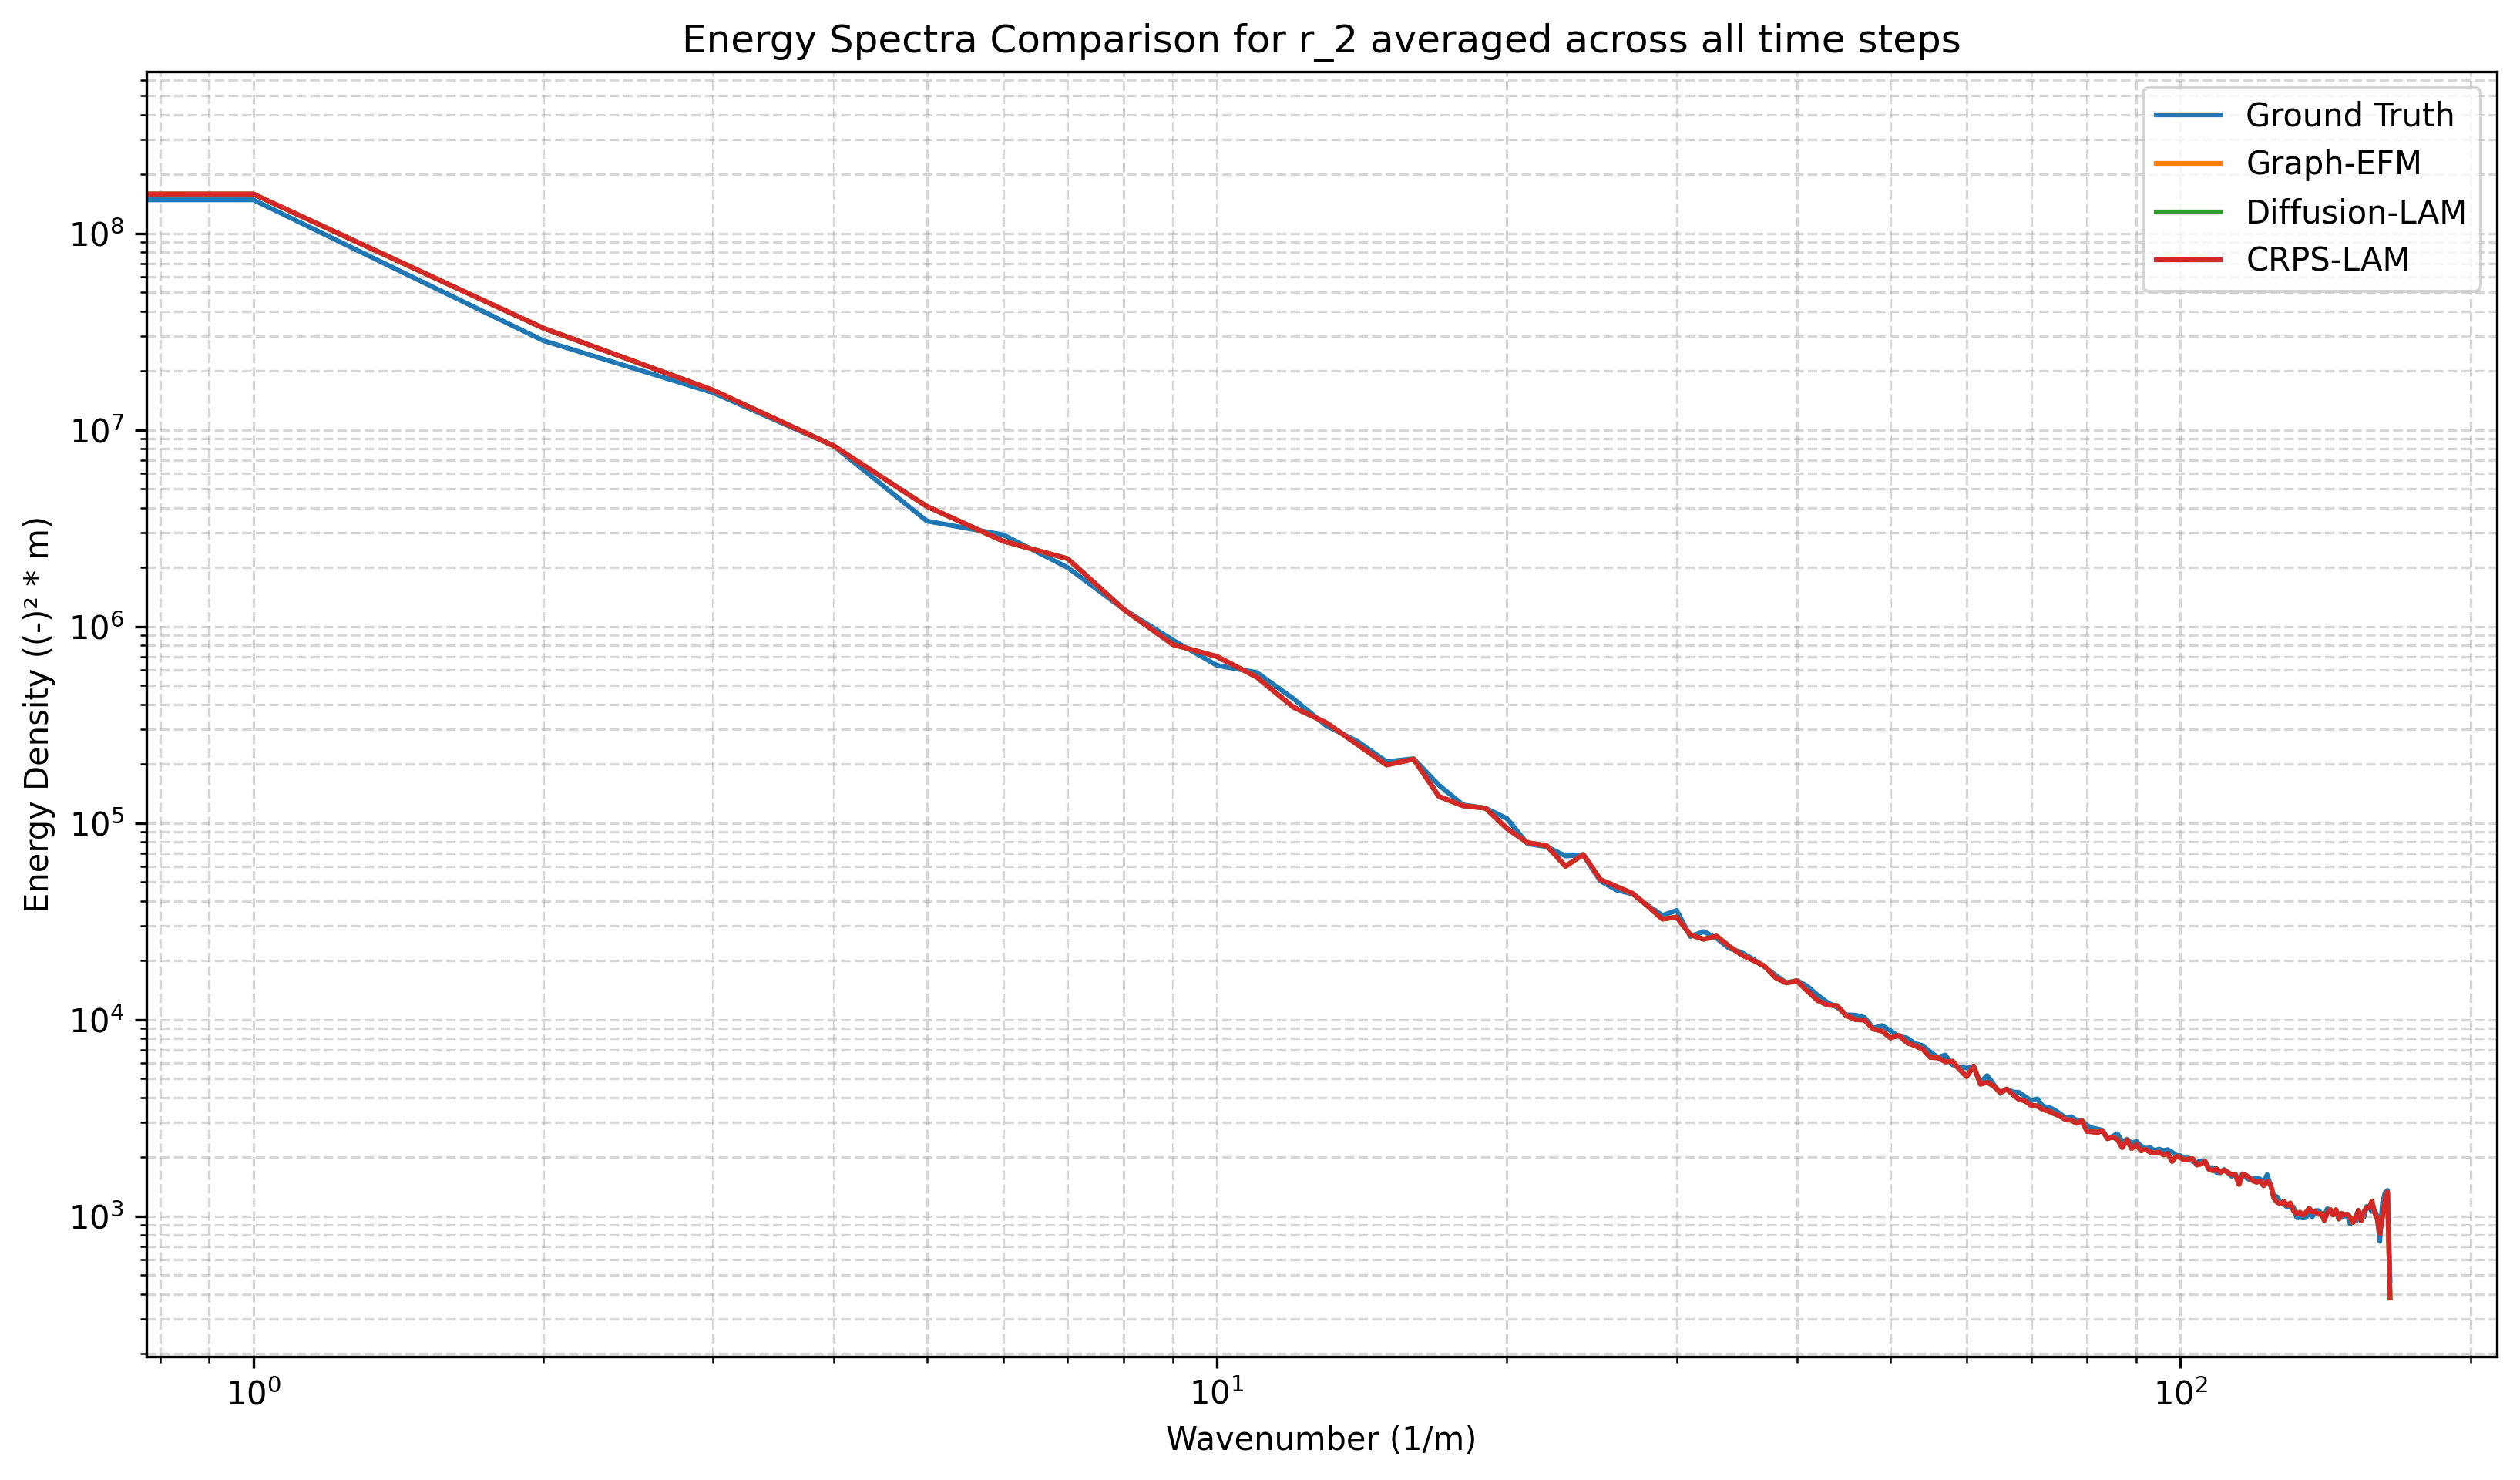

In [32]:
# Plot spectra averaged over lead time for all variables
fig = plot_energy_spectra(models_data["diff"]["predictions"]["target"], models_data, 4, None)

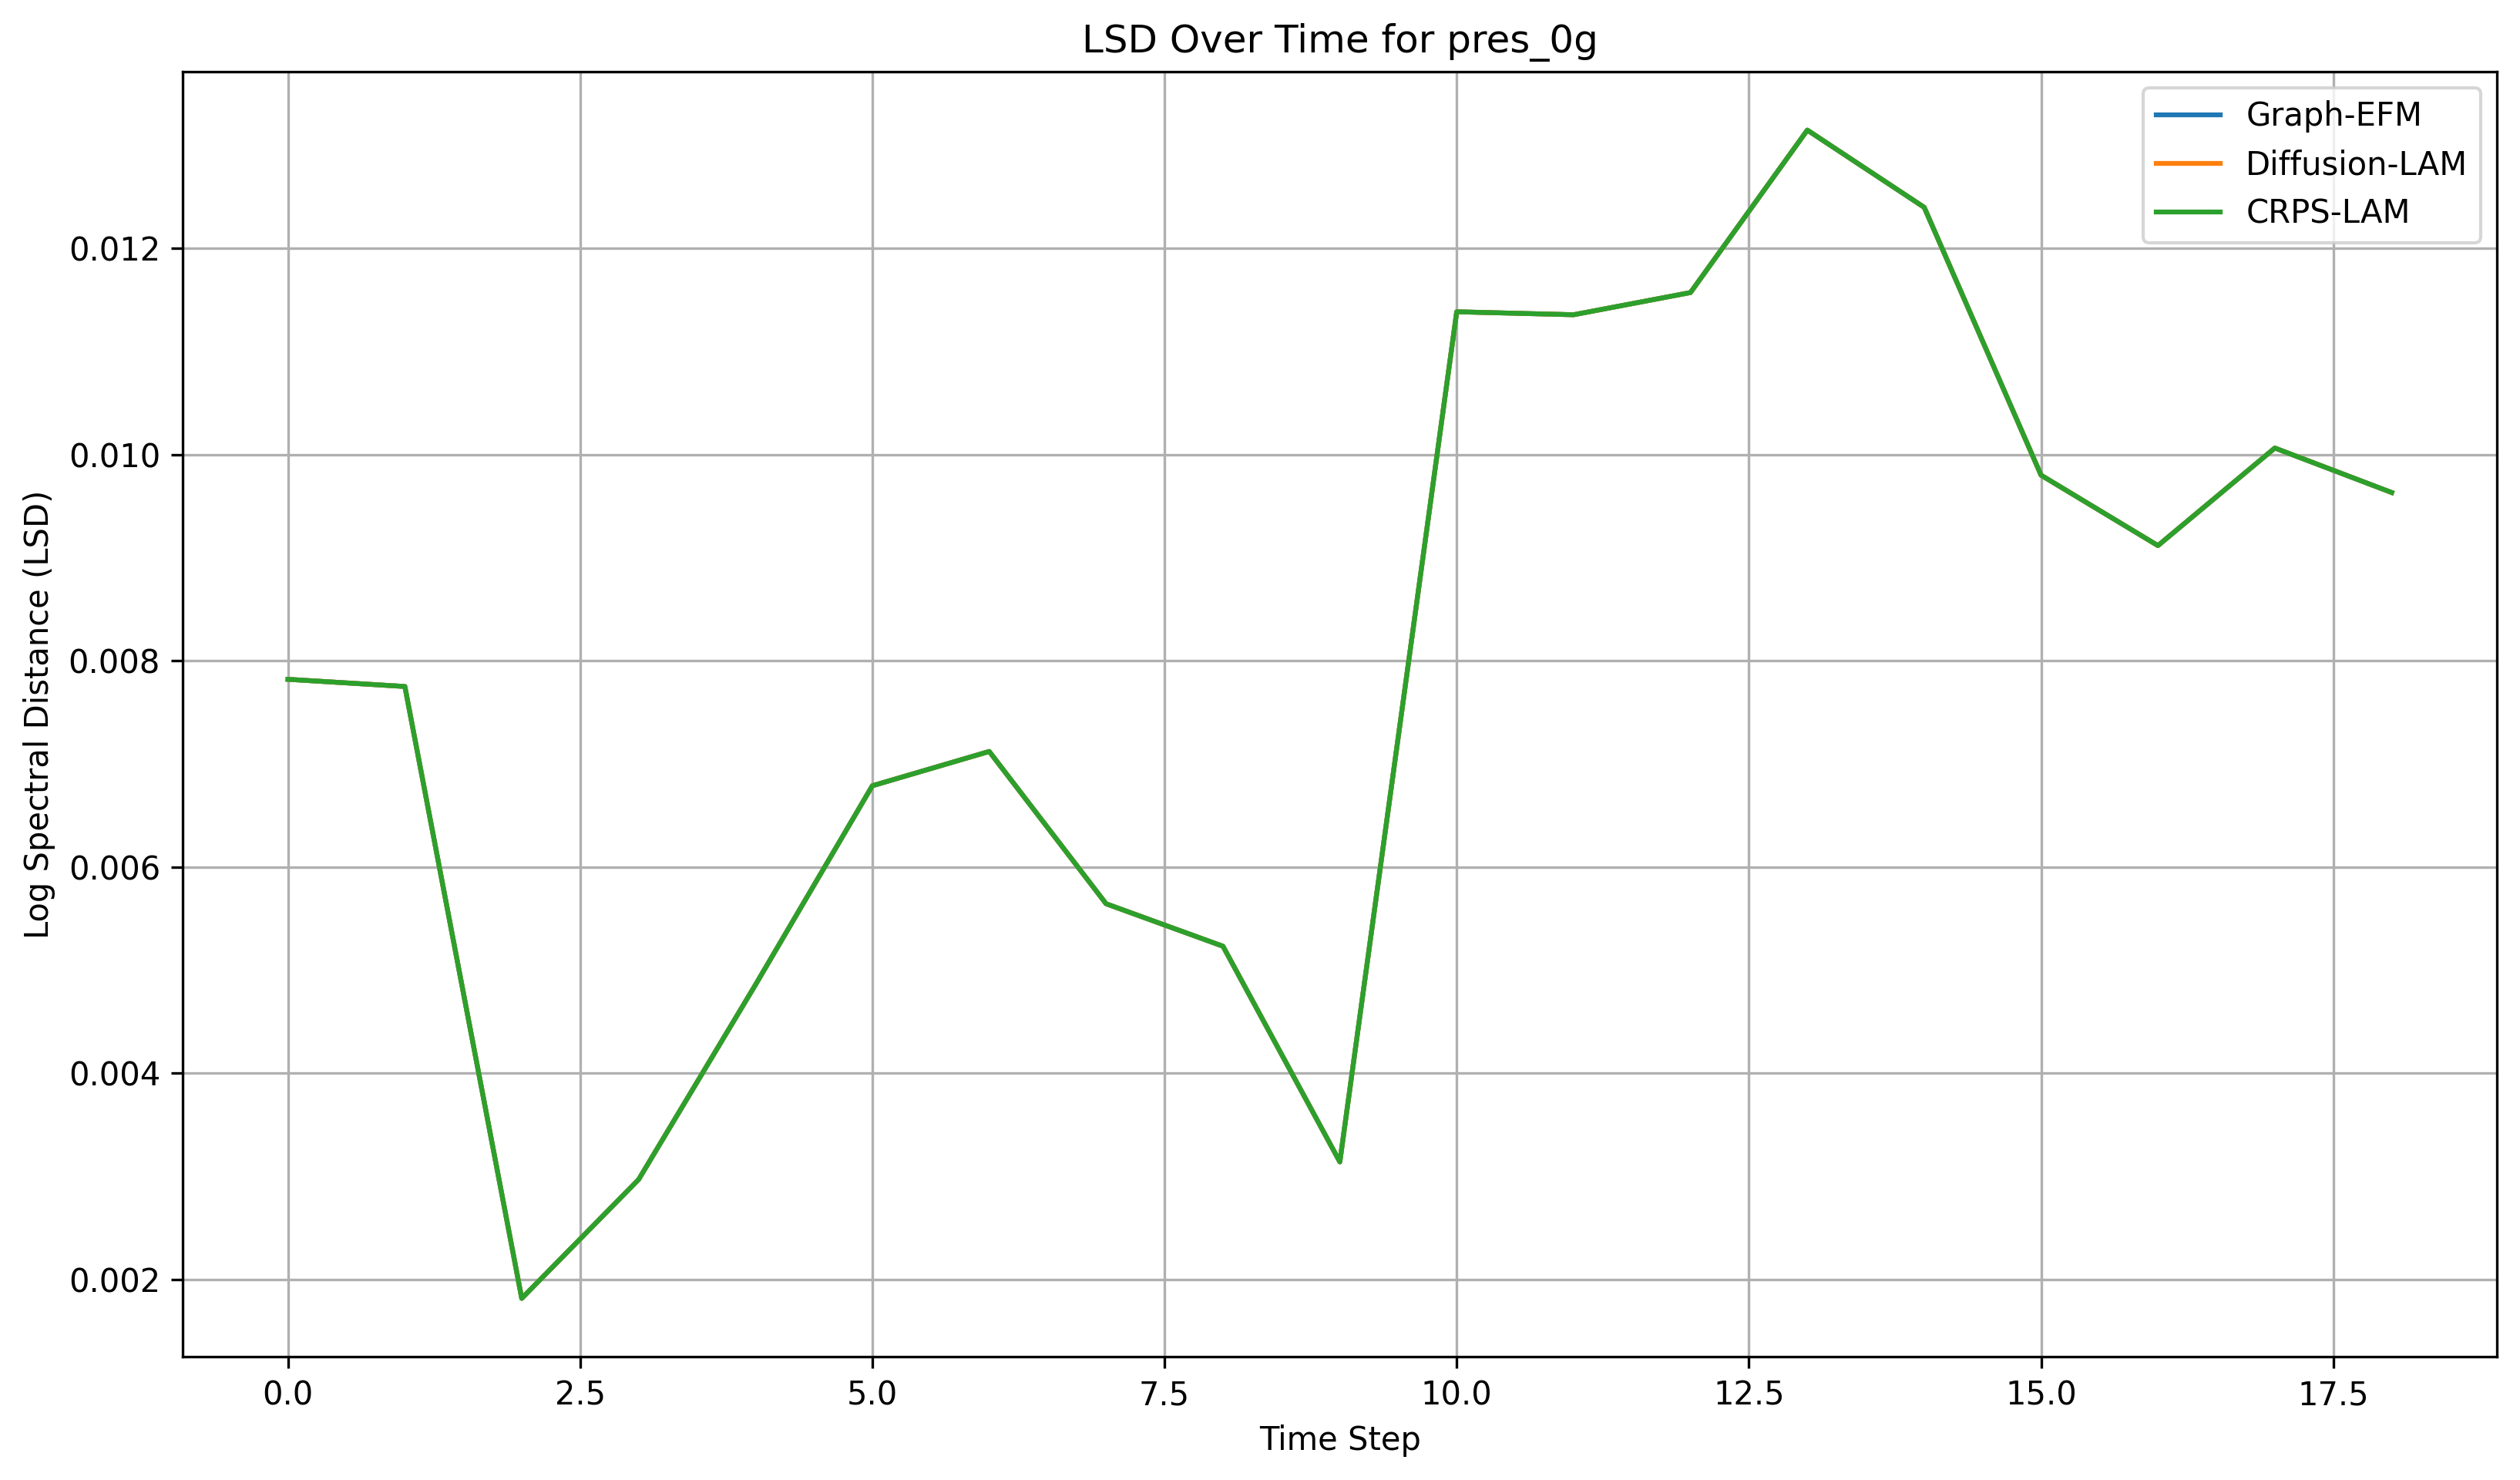

In [34]:
def plot_lsd_over_time(spectra_gt, model_lookup, var=None):
    """Plot Log Spectral Distance (LSD) over time.
    
    Parameters:
    -----------
    spectra_gt : torch.Tensor
        Ground truth spectra with shape [time_steps, variables, spectra_bins]
    model_lookup : dict
        Dictionary of model data
    var : int, optional
        Variable index to plot. If None, averages across all variables.
    """
    fig, ax = plt.subplots(figsize=(11, 6.5), dpi=300)
    time_steps = spectra_gt.shape[0]
    lsd_values = {key: [] for key in model_lookup.keys()}

    if var is not None:
        # Single variable case
        for t in range(time_steps):
            true_spectrum = spectra_gt[t, var, :].cpu().numpy()
            for key, model in model_lookup.items():
                ml_spectrum = model["predictions"]["predictions"][t, var, :].cpu().numpy()
                lsd_ml = metrics.calculate_log_spectral_distance(true_spectrum, ml_spectrum)
                lsd_values[key].append(lsd_ml)
                
        title_suffix = f"for {constants.PARAM_NAMES_SHORT[constants.USED_PARAMS][var]}"
    else:
        # Average across all variables
        num_vars = spectra_gt.shape[1]
        for t in range(time_steps):
            for key, model in model_lookup.items():
                var_lsds = []
                for v in range(num_vars):
                    true_spectrum = spectra_gt[t, v, :].cpu().numpy()
                    ml_spectrum = model["predictions"]["predictions"][t, v, :].cpu().numpy()
                    lsd = metrics.calculate_log_spectral_distance(true_spectrum, ml_spectrum)
                    var_lsds.append(lsd)
                # Average LSD across all variables
                avg_lsd = np.mean(var_lsds)
                lsd_values[key].append(avg_lsd)
                
        title_suffix = "averaged across all variables"

    # Plot LSD values over time for each model
    for key, lsd_list in lsd_values.items():
        ax.plot(range(time_steps), lsd_list, label=model_lookup[key]["model_name"])

    # Customize plot
    ax.set_xlabel("Time Step")
    ax.set_ylabel("Log Spectral Distance (LSD)")
    ax.set_title(f"LSD Over Time {title_suffix}")
    ax.legend(loc='upper right')
    ax.grid(True)
    plt.tight_layout()

    return fig

fig_lsd = plot_lsd_over_time(models_data["diff"]["predictions"]["target"], models_data, 0)

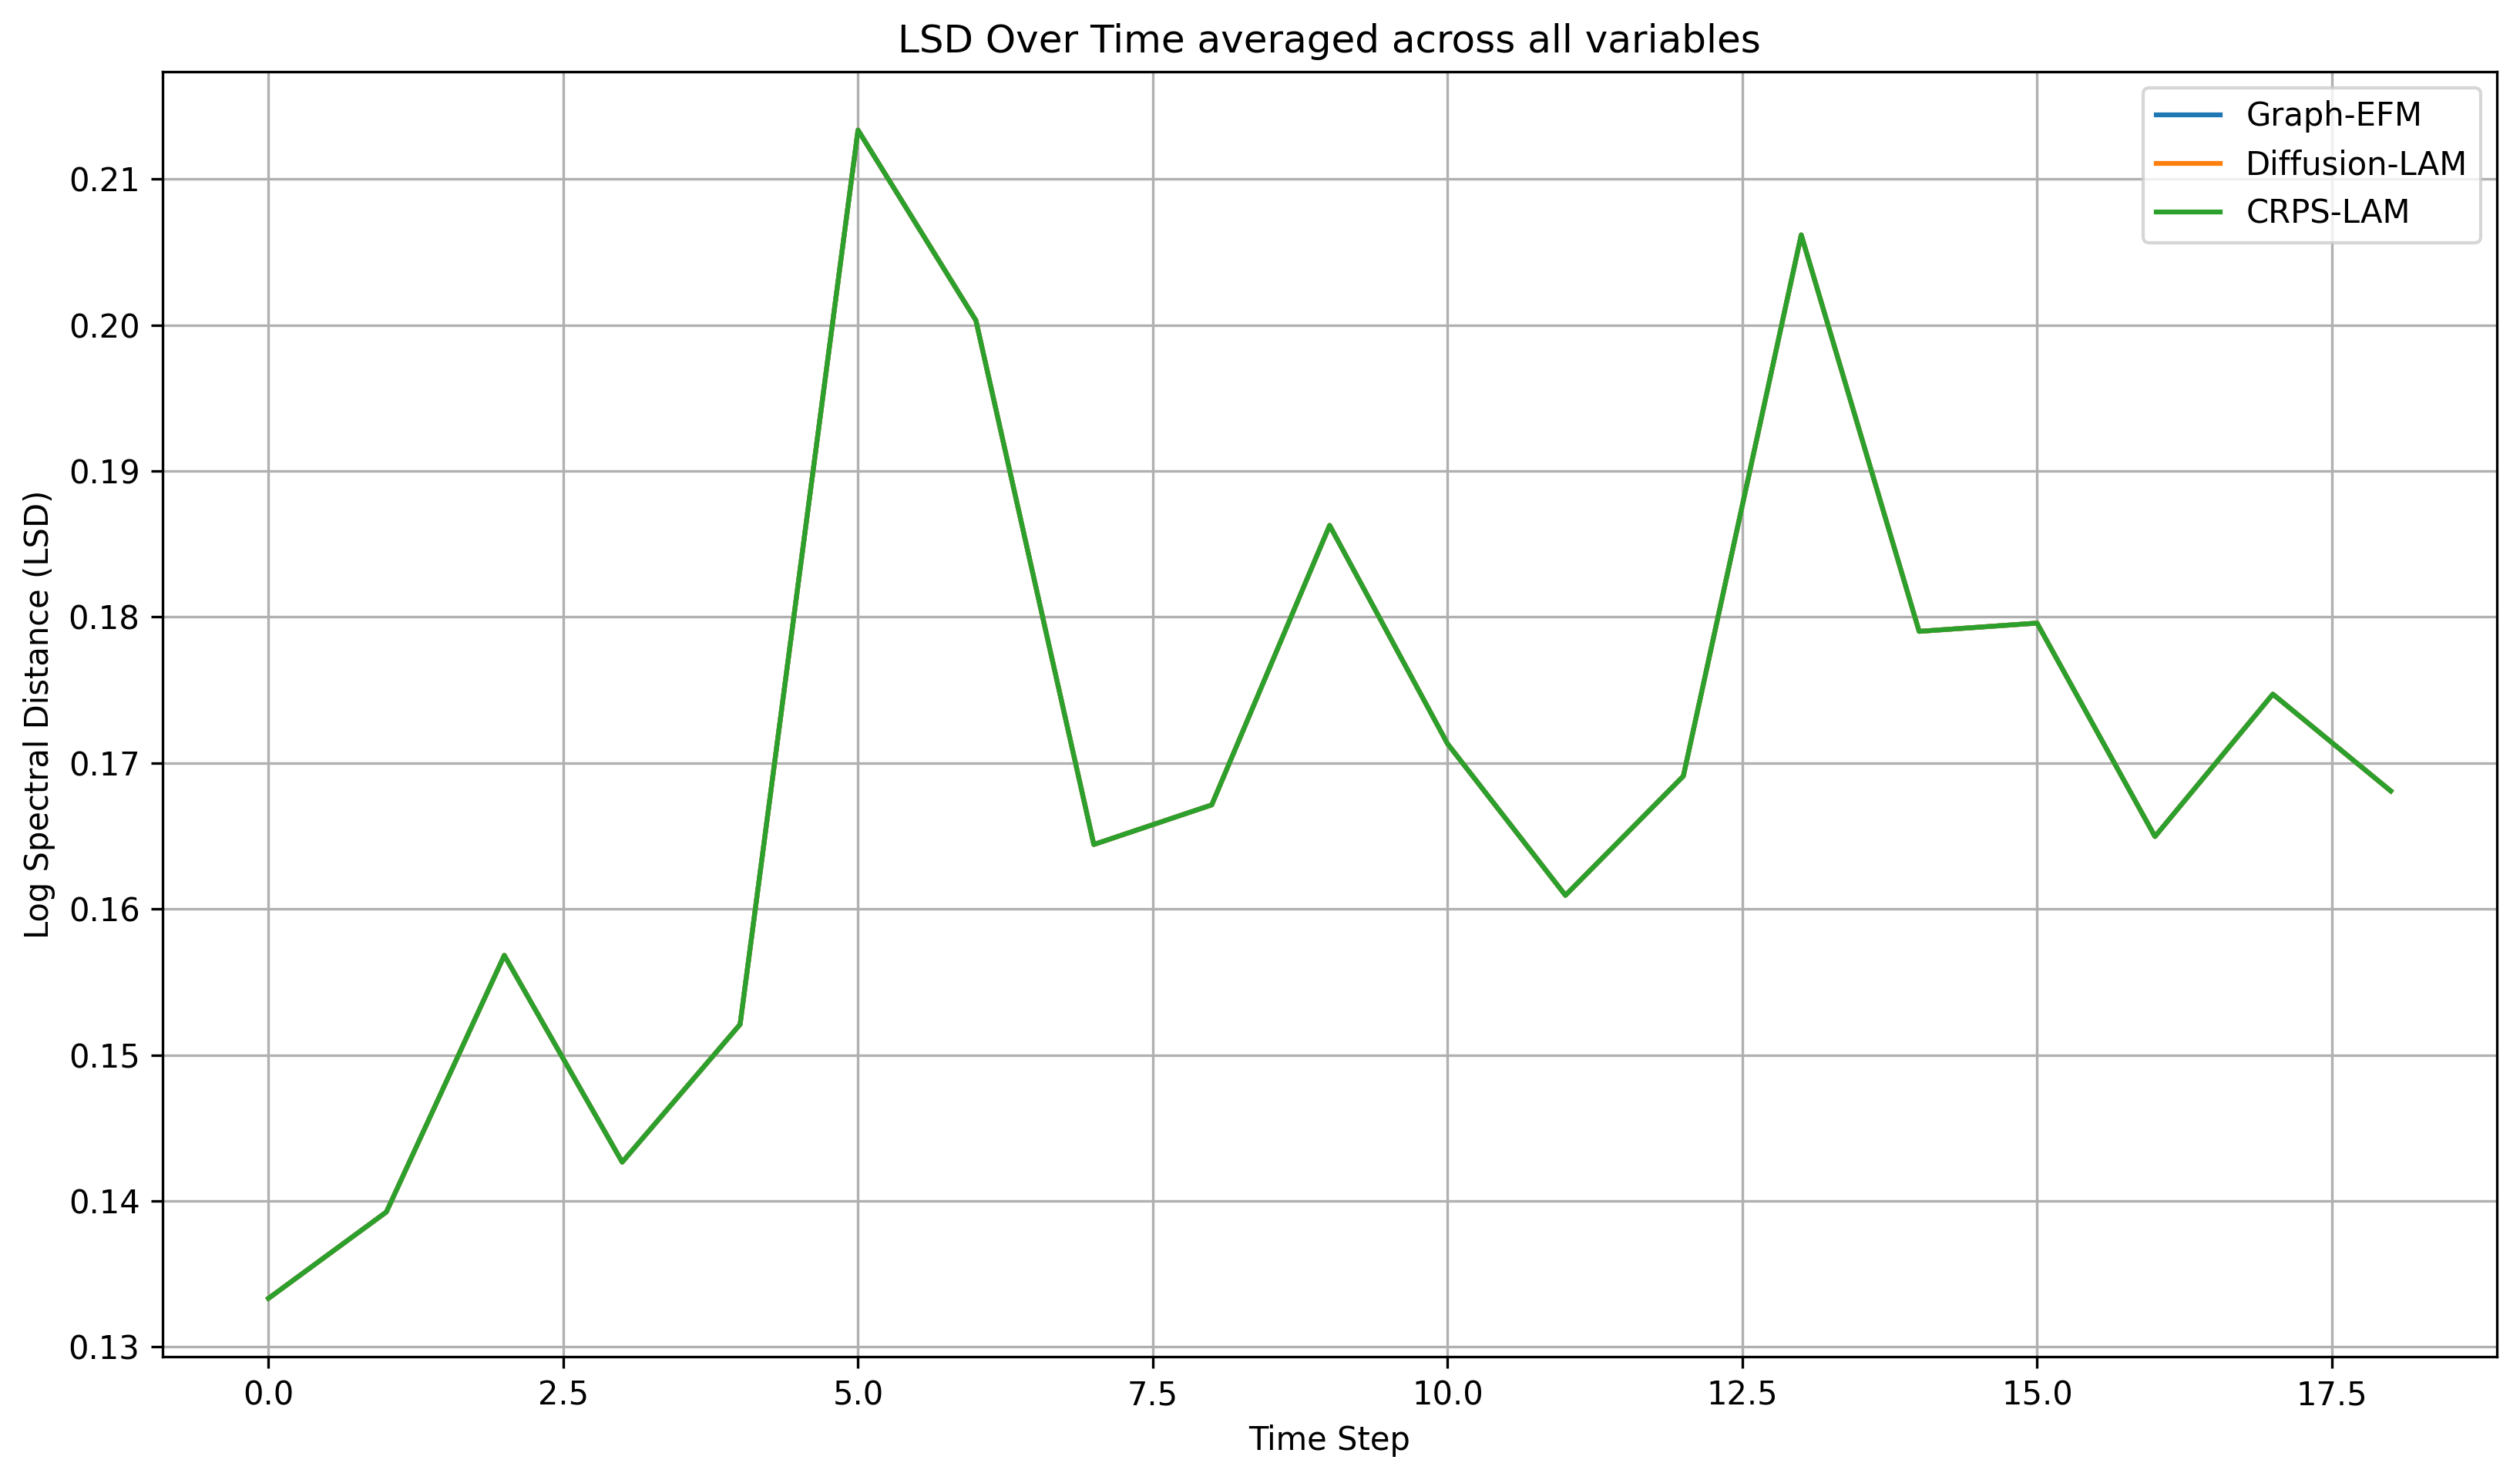

In [33]:
# Plot LSD over time averaged over all variable
fig_lsd = plot_lsd_over_time(models_data["diff"]["predictions"]["target"], models_data, None)